## Q3: Feature Engineering and Regression Pipeline

### Task 1: Date Feature Engineering

In this step, new features are extracted from the transaction_date column to capture temporal patterns in the data.

In [1]:
import pandas as pd

df = pd.read_csv('q3_retail_promotions.csv')

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [2]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [3]:
# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Feature Engineering Explanation

New features were derived from the `transaction_date` column to capture important temporal patterns in the data:

- **year**: Represents the year of the transaction, useful for identifying long-term trends.
- **month**: Captures seasonal variations in sales behavior across different months.
- **day_of_week**: Helps distinguish between weekday and weekend patterns, which can significantly impact customer activity.
- **is_month_end**: A binary feature indicating whether the transaction occurred near the end of the month (day ≥ 25). This can capture increased purchasing behavior due to salary cycles or promotional pushes.

These engineered features enhance the model’s ability to learn time-based patterns and improve prediction accuracy.

## Task 2: Temporal Train-Test Split

In [4]:
# Convert to datetime (safety step)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Sort data by date
df = df.sort_values(by='transaction_date')

# Split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Create train and test sets
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Check shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


### Temporal Train-Test Split Explanation

The dataset was first sorted based on the `transaction_date` column to maintain the chronological order of observations.

The first 80% of the data was used as the training set, while the most recent 20% was used as the test set. This ensures that the model is trained on past data and evaluated on future data.

A random split is inappropriate for time-ordered data because it can introduce **data leakage**, where information from future observations is used during training. This leads to overly optimistic and unrealistic model performance.

By using a temporal split, we simulate real-world conditions where predictions are always made on unseen future data, making the evaluation more reliable.

## Task 3: Preprocessing Pipeline

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# -------------------------------
# 1. Separate features & target
# -------------------------------

# ❗ IMPORTANT: drop transaction_date
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

# -------------------------------
# 2. Define column types
# -------------------------------

categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# -------------------------------
# 3. Create ColumnTransformer
# -------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# -------------------------------
# 4. Create Pipeline
# -------------------------------

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# -------------------------------
# 5. Fit ONLY on training data
# -------------------------------

pipeline.fit(X_train)

# -------------------------------
# 6. Transform both train & test
# -------------------------------

X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

# -------------------------------
# 7. Check shapes
# -------------------------------

print("Processed Train shape:", X_train_processed.shape)
print("Processed Test shape:", X_test_processed.shape)

Processed Train shape: (960, 19)
Processed Test shape: (240, 19)


### Preprocessing Pipeline Explanation

A preprocessing pipeline was built using `ColumnTransformer` to handle different types of features effectively.

- **Categorical features** (`promotion_type`, `location_type`, `store_size`) were transformed using **One-Hot Encoding**, converting them into numerical format suitable for machine learning models.
- **Numerical features** were scaled using **StandardScaler** to ensure all features have a mean of 0 and a standard deviation of 1, preventing features with larger values from dominating the model.

The pipeline was **fitted only on the training data** and then applied to both the training and test sets. This is crucial to avoid **data leakage**, ensuring that information from the test set does not influence the training process.

This approach ensures consistency, improves model performance, and makes the workflow reproducible and suitable for real-world applications.

## Task 4: Model Training and Evaluation


Linear Regression
RMSE: 27.12
MAE: 21.05

Random Forest
RMSE: 30.84
MAE: 24.24


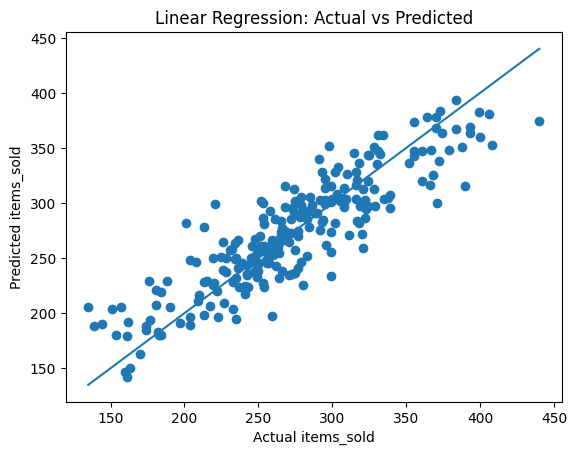

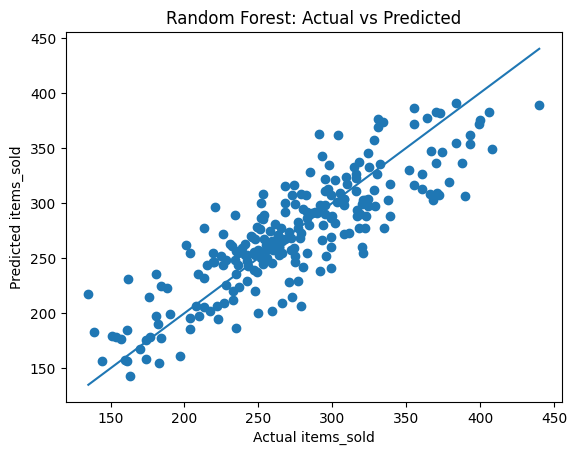


Top 5 Important Features:
                     feature  importance
13          num__is_festival    0.173473
10     cat__store_size_small    0.167683
7   cat__location_type_urban    0.108378
17          num__day_of_week    0.086316
12           num__is_weekend    0.061208


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Pipelines with models
# -------------------------------

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# -------------------------------
# 2. Train models
# -------------------------------

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# -------------------------------
# 3. Predictions
# -------------------------------

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# -------------------------------
# 4. Evaluation Metrics
# -------------------------------

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{model_name}")
    print("RMSE:", round(rmse, 2))
    print("MAE:", round(mae, 2))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

# -------------------------------
# 5. Parity Plot Function
# -------------------------------

def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)

    # Diagonal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(title)
    plt.show()

# Plot for both models
parity_plot(y_test, y_pred_lr, "Linear Regression: Actual vs Predicted")
parity_plot(y_test, y_pred_rf, "Random Forest: Actual vs Predicted")

# -------------------------------
# 6. Feature Importance (Random Forest)
# -------------------------------

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance_df.head(5))

### Model Training and Evaluation Results

Two regression models were trained and evaluated: **Linear Regression** and **Random Forest Regressor**.

#### Model Performance

- **Linear Regression**
  - RMSE: 27.12  
  - MAE: 21.05  

- **Random Forest**
  - RMSE: 30.84  
  - MAE: 24.24  

From the results, Linear Regression performs better than Random Forest on this dataset, as it has lower RMSE and MAE values. This suggests that the relationship between features and `items_sold` is relatively linear, and the simpler model generalizes better.

#### Parity Plot Interpretation

The parity plots compare actual vs predicted values:
- For **Linear Regression**, the points are more closely aligned with the diagonal line, indicating better prediction accuracy.
- For **Random Forest**, there is slightly more spread around the diagonal, indicating higher prediction errors.

A perfect model would have all points exactly on the diagonal line.

#### Feature Importance (Random Forest)

The top 5 most important features identified by the Random Forest model are:

1. `is_festival`  
2. `store_size_small`  
3. `location_type_urban`  
4. `day_of_week`  
5. `is_weekend`  

This indicates that **seasonal and contextual factors** (such as festivals and weekends), along with **store characteristics**, have a strong impact on sales.

#### Conclusion

- Linear Regression performed better on this dataset.
- Temporal and categorical features play a significant role in predicting `items_sold`.
- Feature importance analysis helps in understanding key drivers of sales, which can support business decision-making.